
# Download Swot from AVISO
This notebook explains how to explore and retrieve available SWOT LR data from AVISO's THREDDS Data Server and FTP Server, presented [here](https://www.aviso.altimetry.fr/en/missions/current-missions/swot/access-to-data.html).

L2 data can be explored at: https://tds.aviso.altimetry.fr/thredds/L2/L2-SWOT-DATA/L2-SWOT.html

L3 data can be explored at: https://tds.aviso.altimetry.fr/thredds/L3/dataset-l3-swot-karin-nadir-pre-validated.html


**Data update May 2025**  
SWOT L3_LR_SSH (2-km) Version 2.0.1
You can find more details about v2.0.1 content in the short presentation here  
Products: Basic and Expert versions (Landing Page is here)  
Calibration phase: Cycles 474-578  
Science phase: Cycles 1-ongoing  
Unsmoothed Version: Available for the Calibration phase (Cycles 474–578) and Science phase (Cycles 1–16 only)
  

**Data update Nov 2025**  
The third release of the Level-3 products is available

Since the release of the L3 version 2.0.1, we have received your feedback and suggestions, and we have been working on new or improved algorithms/corrections/models. The new release, or v3.0, is now available on AVISO (1). At the moment, only the 2km variants are online, and the 250-m is expected to arrive early next year.

In addition to the upgrades on the basic & expert product variants, a new 'technical L3' variant is being added (ETA: one week or two). Following multiple requests from community experts, the purpose of the technical L3 is to provide additional and optional content such as alternative geophysical models, or algorithms, for specific expert studies or if you want to customize the L3 baseline. We have a lot of flexibility on this new product:  if anything is missing, your feedback would be most welcome.

We have put together this short presentation with a comprehensive outline of the main changes and impacts. You can also find more details and examples in the handbook (v3) with the changes and some known limitations.
  

**For AVISO Account Holders**
If you already have an AVISO account, you can access the data via the following services:

FTP access: ftp-access.aviso.altimetry.fr:21
SFTP access: ftp-access.aviso.altimetry.fr:2122
paths
/swot_products/l3_karin_nadir/l3_lr_ssh/v3_0
/swot_products/l3_karin/l3_lr_wind_wave/v3_
THREDDS Data Server (TDS)
No account required: TDS access is open and does not require an AVISO account.
L3_LR_SSH TDS Access: THREDDS Catalog for L3_LR_SSH v3_0 https://tds-odatis.aviso.altimetry.fr/thredds/catalog/dataset-l3-swot-karin-nadir-validated/l3_lr_ssh/v3_0/catalog.html  
L3_LR_WIND_WAVE TDS Access: THREDDS Catalog for L3_LR_WIND_WAVE v2.0


## Tutorial Objectives
* Discover Aviso's Thredds Data Server catalogue
* Download files through HTTP and FTP
* Download data subset through Opendap



## Import + code



In [2]:
import os
import re
from getpass import getpass
import requests as rq
import ftplib
import xarray as xr
from xarray.backends import PydapDataStore
import pydap
from siphon.catalog import TDSCatalog
import numpy as np

def _get_filename_from_cd(cd):
    """ Get filename from content-disposition """
    if not cd:
        return None
    fname = re.findall('filename="(.+)"', cd)
    if len(fname) == 0:
        return None
    return fname[0]

def http_download_file(dataset_url:str, output_path:str,filename):
    response = rq.get(dataset_url, auth=(username, password))
    
    #filename = _get_filename_from_cd(response.headers['content-disposition']) # SR: this was giving me an error so I added filename is argument in function
    file_path = os.path.join(output_path, filename)
    
    open(file_path, 'wb').write(response.content)
    return file_path

def _download_file(ftp:str, filename:str, target_directory:str):
    try:
        local_filepath = os.path.join(target_directory, filename)
        with open(local_filepath, 'wb') as file:
            ftp.retrbinary('RETR %s' % filename, file.write)
            print(f"Downloaded {filename} to {target_directory}")
            return local_filepath
    except Exception as e:
        print(f"Error downloading {filename}: {e}")
        
def ftp_download_file(ftp_path:str, filename:str, output_path:str):
    # Set up FTP server details

    ftpAVISO = 'ftp-access.aviso.altimetry.fr'
    try:
        # Logging into FTP server using provided credentials
        with ftplib.FTP(ftpAVISO) as ftp:
            ftp.login(username, password)
            ftp.cwd(ftp_path)
            print(f"Connection Established {ftp.getwelcome()}")

            # Check if the file exists in the directory
            if filename in ftp.nlst():
                return _download_file(ftp, filename, output_path)
            else:
                print(f"File {filename} does not exist in the directory {ftp}.")
    except ftplib.error_perm as e:
        print(f"FTP error: {e}")
    except Exception as e:
        print(f"Error: {e}")


def open_opendap_dataset(dataset_url):
    session = rq.Session()
    session.auth = (username, password)
    store = PydapDataStore.open(dataset_url, session=session, timeout=300, user_charset='UTF-8')
    return xr.open_dataset(store)

## Parameters
Define output folder to save results



In [3]:
phase = 'Science' # CalVal, Science
# output_dir = "/srv/data/SWOT/L3/"+phase+"/v2_0_1/"
version = 'v3_0'
output_dir = f"/srv/data/SWOT/L3/{phase}/{version}/"
proc = 'forward'

### Authentication parameters
Enter your AVISO+ credentials



In [4]:
username = 'sryan@whoi.edu'
password = 'at1bVc'#getpass(f"Enter password for {username}:")

## Download files through HTTP
To find the data you want to download, you can explore the [Swot LR L2](https://tds.aviso.altimetry.fr/thredds/L2/L2-SWOT-DATA/L2-SWOT.html) or [Swot LR L3](https://tds.aviso.altimetry.fr/thredds/L3/L3.html) catalogues.

Copy the **FileServer** url to download data through HTTP : 
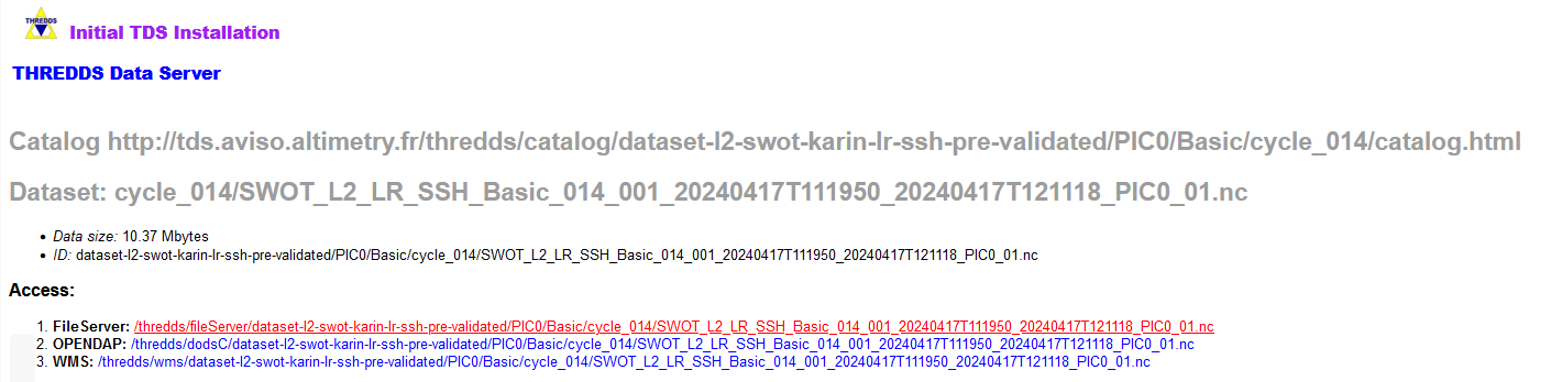

### Swot LR L3 data



Transition from v.2 to v.3 involves reprocessed data prior to cycle 32. Hence if all data for a new region is downloaded one needs to adjust links accroding to prior and after cycle 32. 

In [5]:
# define files to be downloaded
# Science phase
# cycle = np.arange(1,36)
# passes = [7, 20, 35, 46, 48, 61, 63, 74, 89, 102, 117, 130, 145, 158, 173, 186, 201, 214, 229, 242, 257,
#           268, 270, 296, 298, 324, 326, 339, 341, 352, 367, 386, 395, 408, 423, 436, 451, 464, 479, 492,
#           507, 520, 535, 548, 563, 576]
# passes = [
#     5, 7, 18, 20, 33, 35, 46, 48, 61, 63, 74, 76, 89, 91, 102,
#     117, 119, 130, 145, 147, 158, 173, 186, 201, 212, 214, 229,
#     240, 242, 257, 268, 270, 285, 296, 298, 311, 313, 324, 326,
#     339, 341, 352, 354, 367, 369, 380, 395, 397, 408, 423, 425,
#     436, 451, 453, 464, 479, 490, 492, 507, 518, 520, 535, 546,
#     548, 563, 574, 576
# ]
cycle = np.arange(49,50) # prior to processing change
# cycle = np.arange(32,44) #
fname = "./passID_files/passIDs_Ross_science_160_-78_-150_-70.txt"
passes = np.loadtxt(fname, skiprows=1, dtype=int)



# CalVal phase
# cycle = np.arange(478,579) # cycles 526 and 527 are missing
# passes = [22,9,20,7]

# Antarctica
# cycle = np.arange(478,578) # starting at 478 since not all passes available before 
# # Path to the uploaded file
# fname = "./passIDs_Amery_60_-75_80_-63.txt"
# passes = np.loadtxt(fname, skiprows=1, dtype=int)



**NEED TO ADJUST CATALOG URL**  



**Note**

For newer version, older files are being reprocessed --> changes url

In [6]:
# for v3_0 define if reprocessed or forward data (change around cycle 32)

for c in cycle:
    print(c)
    # Replace this URL with the URL of your THREDDS catalog
    # catalog_url = f'https://tds.aviso.altimetry.fr/thredds/catalog/dataset-l3-swot-karin-nadir-validated/l3_lr_ssh/v1_0_2/Expert/cycle_{c:03}/catalog.html'
    # catalog_url = f'https://tds.aviso.altimetry.fr/thredds/catalog/dataset-l3-swot-karin-nadir-validated/l3_lr_ssh/v2_0_1/Expert/cycle_{c:03}/catalog.html'
    if c<32 or c>400:
        proc = 'reproc'
        catalog_url = f'https://tds-odatis.aviso.altimetry.fr/thredds/catalog/dataset-l3-swot-karin-nadir-validated/l3_lr_ssh/{version}/Expert/reproc/cycle_{c:03}/catalog.xml'
    elif c>=32:
        proc = 'forward'
        catalog_url = f'https://tds-odatis.aviso.altimetry.fr/thredds/catalog/dataset-l3-swot-karin-nadir-validated/l3_lr_ssh/{version}/Expert/forward/cycle_{c:03}/catalog.xml'
    # Create a TDSCatalog object
    try:
        catalog = TDSCatalog(catalog_url)
        # Get the list of datasets in the catalog
        datasets = catalog.datasets
        # print(datasets)
    except:
        print(f'file for cycle {c} not available')
        continue
    
    
    # find matching file names
    # Function to extract cycle and pass numbers
    def extract_cycle_and_pass(filename):
        match = re.search(r"Expert_(\d{3})_(\d{3})_", str(filename))  # Extract cycle and pass numbers
        if match:
            cycle_number = int(match.group(1))  # First three digits
            pass_number = int(match.group(2))   # Next three digits
            return cycle_number, pass_number
        return None, None
    
    # create list with filenames of selected passes for each cycle
    def find_filename(c,passes):
        filelist = []
        # Identify files with correct pass numbers
        for file in datasets:
            c, pass_num = extract_cycle_and_pass(file)
            if pass_num in passes:
                filelist.append(file)
        return filelist
    
    list_cycle = find_filename(c,passes)

    # for i in range(len(list_cycle)):
    #     l3_dataset_url = f"https://tds.aviso.altimetry.fr/thredds/fileServer/dataset-l3-swot-karin-nadir-validated/l3_lr_ssh/v2_0_1/Expert/cycle_{c:03}/{list_cycle[i]}"
    #     l3_file = http_download_file(l3_dataset_url, output_dir,list_cycle[i])
    #     print(f'{l3_dataset_url} downloaded')

    for fname in list_cycle:
            print(fname)
            local_path = os.path.join(output_dir, fname)
            if not os.path.isfile(local_path):
                url = (
                    "https://tds-odatis.aviso.altimetry.fr/thredds/fileServer/"
                    "dataset-l3-swot-karin-nadir-validated/"
                    f"l3_lr_ssh/{version}/Expert/{proc}/cycle_{c:03}/{fname}"
                )
                http_download_file(url, output_dir, fname)
                print(f"  → downloaded {fname}")
            else:
                print(f"  → {fname} already exists, skipping")

49
SWOT_L3_LR_SSH_Expert_049_002_20260417T182903_20260417T192029_v3.0.nc
  → SWOT_L3_LR_SSH_Expert_049_002_20260417T182903_20260417T192029_v3.0.nc already exists, skipping
SWOT_L3_LR_SSH_Expert_049_004_20260417T201157_20260417T210323_v3.0.nc
  → SWOT_L3_LR_SSH_Expert_049_004_20260417T201157_20260417T210323_v3.0.nc already exists, skipping
SWOT_L3_LR_SSH_Expert_049_006_20260417T215450_20260417T224616_v3.0.nc
  → SWOT_L3_LR_SSH_Expert_049_006_20260417T215450_20260417T224616_v3.0.nc already exists, skipping
SWOT_L3_LR_SSH_Expert_049_007_20260417T224617_20260417T233744_v3.0.nc
  → SWOT_L3_LR_SSH_Expert_049_007_20260417T224617_20260417T233744_v3.0.nc already exists, skipping
SWOT_L3_LR_SSH_Expert_049_008_20260417T233744_20260418T002910_v3.0.nc
  → SWOT_L3_LR_SSH_Expert_049_008_20260417T233744_20260418T002910_v3.0.nc already exists, skipping
SWOT_L3_LR_SSH_Expert_049_009_20260418T002911_20260418T012037_v3.0.nc
  → SWOT_L3_LR_SSH_Expert_049_009_20260418T002911_20260418T012037_v3.0.nc already 

KeyboardInterrupt: 